   Hopitaux   Province
0         2    Guelmim
1         1    Tan Tan
2         1   Assa-Zag
3         1  Sidi Ifni
   Lits   Province
0   161    Guelmim
1   105    Tan Tan
2    65   Assa-Zag
3    44  Sidi Ifni
    Province  Medecins_generalistes  Medecins_specialistes  Total_medecins
0    Guelmim                     26                     38              64
1    Tan Tan                      5                     25              30
2   Assa-Zag                      0                     16              16
3  Sidi Ifni                      7                     22              29


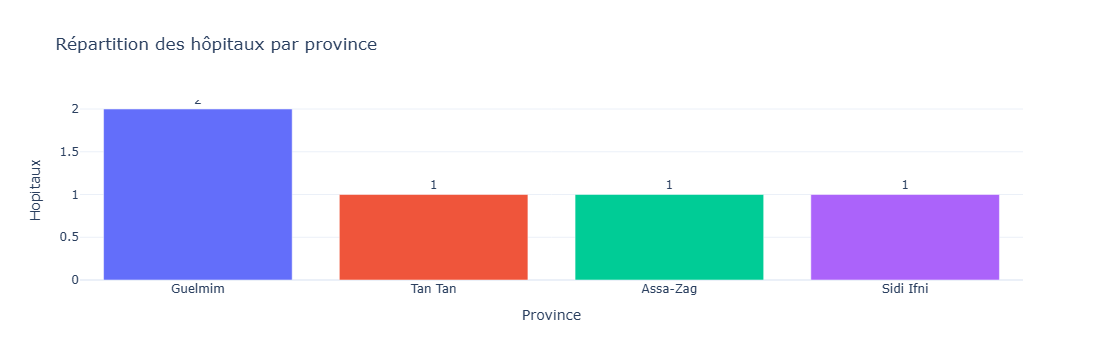

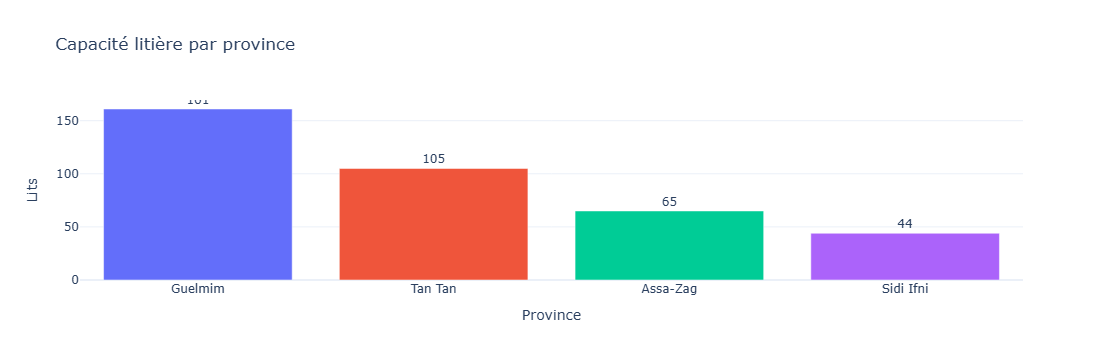

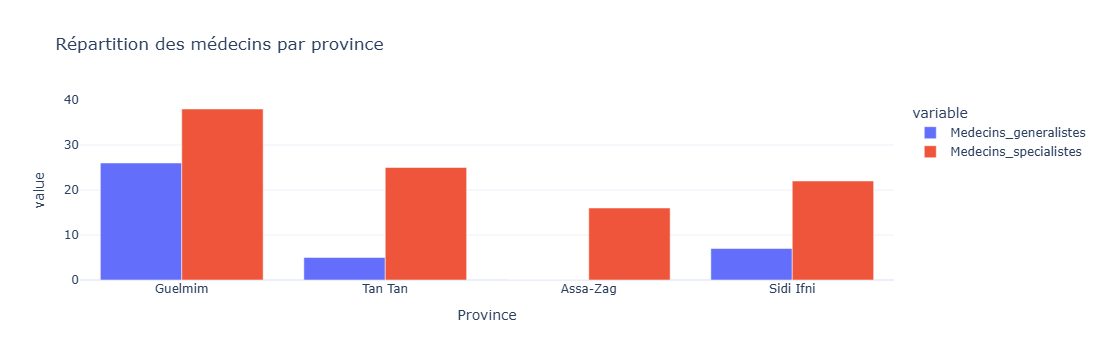

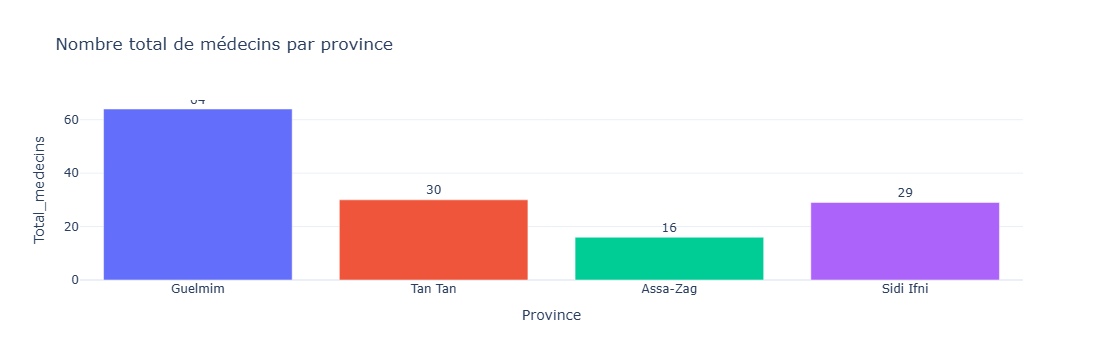

In [8]:
import pandas as pd
import plotly.express as px

# =====================================================
# Tableau 3 : Hôpitaux
# =====================================================

tableau_3 = pd.read_csv(
    "../data/Tableau_3_FR.csv",
    header=None,
    skiprows=1
)

tableau_3 = tableau_3.iloc[:, 1:3]
tableau_3.columns = ["Hopitaux", "Province"]

tableau_3["Hopitaux"] = pd.to_numeric(
    tableau_3["Hopitaux"],
    errors="coerce"
)

tableau_3 = tableau_3.dropna()


# =====================================================
# Tableau 4 : Lits
# =====================================================

tableau_4 = pd.read_csv(
    "../data/Tableau_4_FR.csv",
    header=None,
    skiprows=2
)

tableau_4 = tableau_4.iloc[:, 1:3]
tableau_4.columns = ["Lits", "Province"]

tableau_4["Lits"] = pd.to_numeric(
    tableau_4["Lits"],
    errors="coerce"
)

tableau_4 = tableau_4.dropna()


# =====================================================
# Tableau 7 : Médecins
# =====================================================

tableau_7 = pd.read_csv(
    "../data/Tableau_7_1_FR.csv"
)

tableau_7.columns = [
    "Province",
    "Medecins_generalistes",
    "Medecins_specialistes",
    "Total_medecins"
]

# =====================================================
# Suppression de la ligne Total
# =====================================================

tableau_3_graph = tableau_3[
    tableau_3["Province"] != "Total"
]

tableau_4_graph = tableau_4[
    tableau_4["Province"] != "Total"
]

tableau_7_graph = tableau_7[
    tableau_7["Province"] != "Total"
]


# =====================================================
# Vérification
# =====================================================

print(tableau_3_graph)
print(tableau_4_graph)
print(tableau_7_graph)


# =====================================================
# Graphique 1 : Hôpitaux
# =====================================================

fig1 = px.bar(
    tableau_3_graph,
    x="Province",
    y="Hopitaux",
    text="Hopitaux",
    color="Province",
    title="Répartition des hôpitaux par province"
)

fig1.update_traces(textposition="outside")
fig1.update_layout(
    template="plotly_white",
    showlegend=False
)

fig1.show()


# =====================================================
# Graphique 2 : Lits
# =====================================================

fig2 = px.bar(
    tableau_4_graph,
    x="Province",
    y="Lits",
    text="Lits",
    color="Province",
    title="Capacité litière par province"
)

fig2.update_traces(textposition="outside")
fig2.update_layout(
    template="plotly_white",
    showlegend=False
)

fig2.show()


# =====================================================
# Graphique 3 : Médecins
# =====================================================

fig3 = px.bar(
    tableau_7_graph,
    x="Province",
    y=[
        "Medecins_generalistes",
        "Medecins_specialistes"
    ],
    barmode="group",
    title="Répartition des médecins par province"
)

fig3.update_layout(
    template="plotly_white"
)

fig3.show()


# =====================================================
# Graphique 4 : Total médecins
# =====================================================

fig4 = px.bar(
    tableau_7_graph,
    x="Province",
    y="Total_medecins",
    text="Total_medecins",
    color="Province",
    title="Nombre total de médecins par province"
)

fig4.update_traces(textposition="outside")

fig4.update_layout(
    template="plotly_white",
    showlegend=False
)

fig4.show()